In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("data_science_job.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


## Applying CCA(Complete Case Analysis)

In [3]:
df.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [4]:
df.shape

(19158, 13)

In [5]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [6]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
14340,0.897,no_enrollment,NaN,20.0,15.0
14184,0.920,no_enrollment,Masters,NaN,136.0
10289,0.558,Full time course,High School,4.0,87.0
2490,0.689,no_enrollment,Graduate,5.0,11.0
5047,0.925,no_enrollment,Graduate,10.0,162.0


In [7]:
len(df[cols].dropna()) / len(df) * 100

89.68577095730244

In [8]:
new_df = df[cols].dropna()
new_df.shape, df.shape

((17182, 5), (19158, 13))

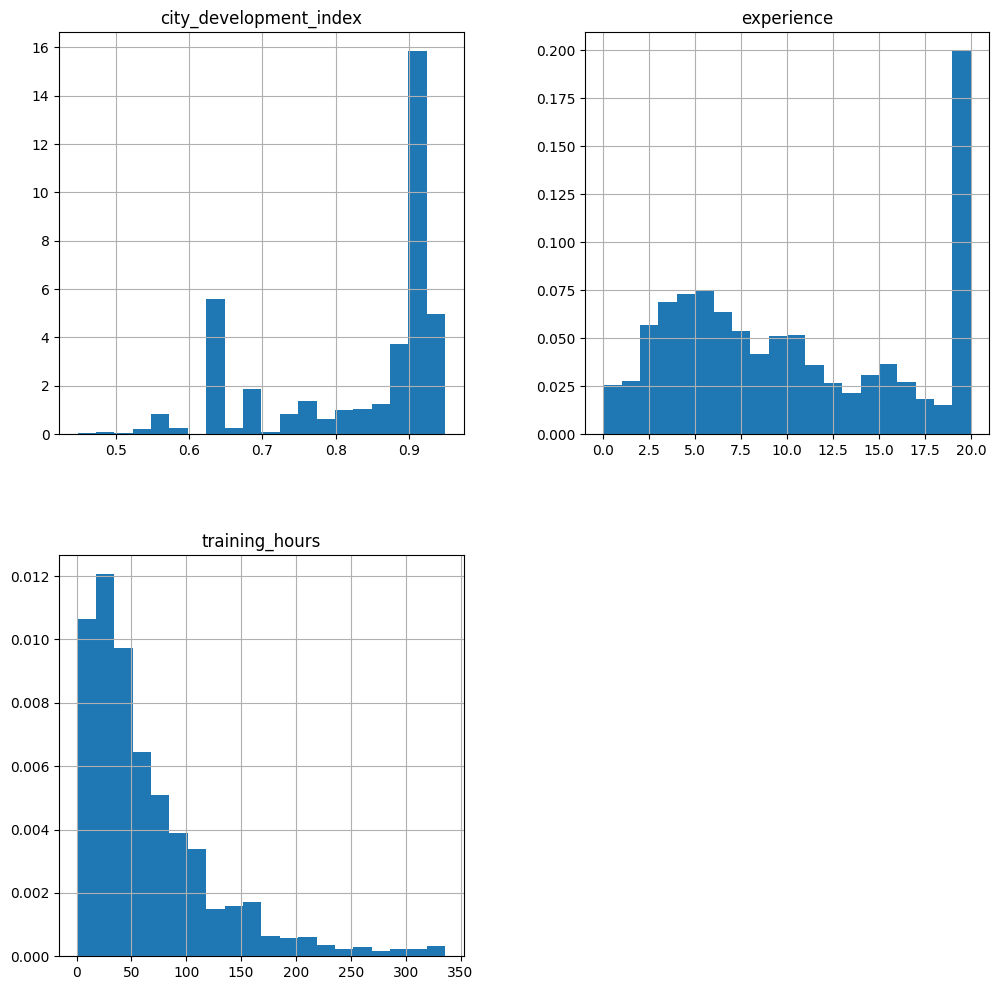

In [9]:
new_df.hist(bins=20, density=True, figsize=(12, 12))
plt.show()

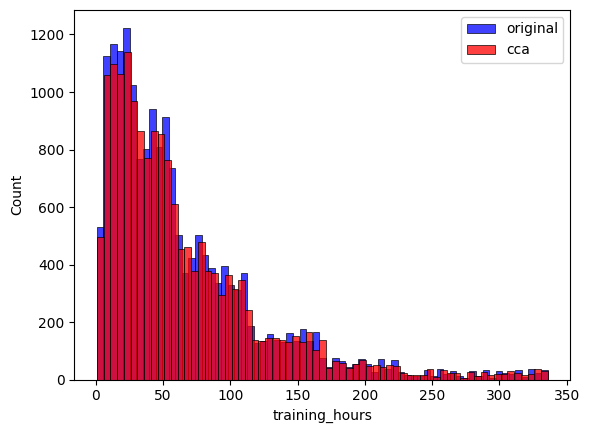

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.histplot(df['training_hours'], ax=ax, color='blue', label='original')
sns.histplot(new_df['training_hours'], ax=ax, color='red', label='cca')

ax.legend()
plt.show()

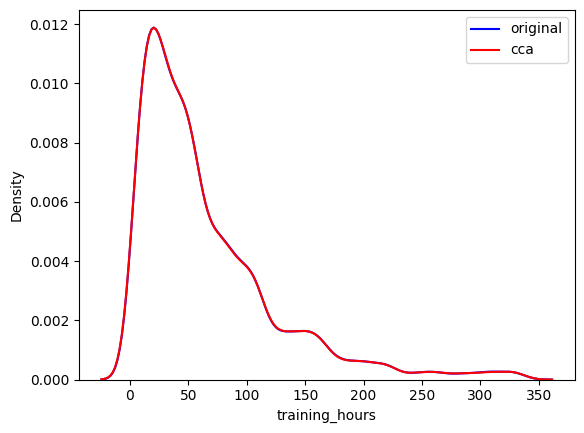

In [18]:
fig = plt.figure()
ax1 = fig.add_subplot(111)
sns.kdeplot(df['training_hours'], ax=ax1, color='blue', label='original')
sns.kdeplot(new_df['training_hours'], ax=ax1, color='red', label='cca')
ax1.legend()
plt.show()

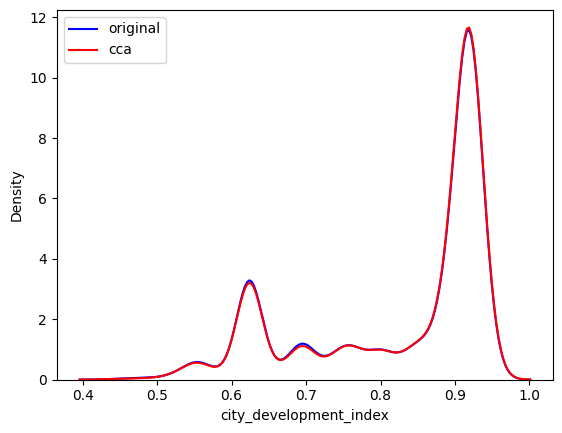

In [19]:
fig = plt.figure()
ax1 = fig.add_subplot(111)
sns.kdeplot(df['city_development_index'], ax=ax1, color='blue', label='original')
sns.kdeplot(new_df['city_development_index'], ax=ax1, color='red', label='cca')
ax1.legend()
plt.show()

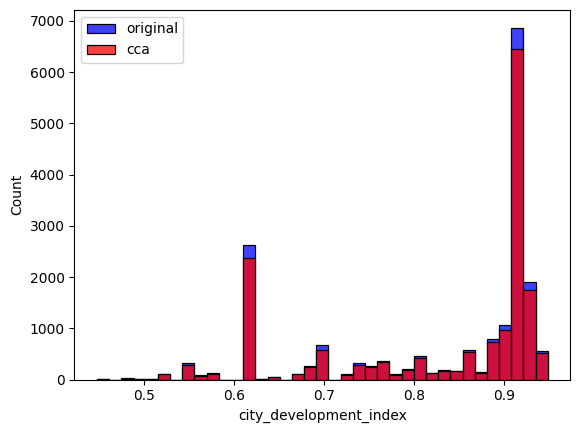

In [20]:
fig, ax = plt.subplots()

sns.histplot(df['city_development_index'], ax=ax, color='blue', label='original')
sns.histplot(new_df['city_development_index'], ax=ax, color='red', label='cca')

ax.legend()
plt.show()

In [22]:
temp = pd.concat([

    df['enrolled_university'].value_counts() / len(df) * 100,
    new_df['enrolled_university'].value_counts() / len(new_df) * 100
], axis=1)
temp.columns = ['original', 'cca']
temp

,original,cca
enrolled_university,,
no_enrollment,72.121307,73.518799
Full time course,19.610607,20.073333
Part time course,6.253262,6.407869


In [23]:
temp2 = pd.concat([

    df['education_level'].value_counts() / len(df) * 100,
    new_df['education_level'].value_counts() / len(new_df) * 100
], axis=1)  
temp2.columns = ['original', 'cca']
temp2

,original,cca
education_level,,
Graduate,60.538678,61.983471
Masters,22.763336,23.408218
High School,10.528239,10.737982
Phd,2.160977,2.211617
Primary School,1.607683,1.658713


## Handling missing data | Numerical Data | Simple Imputer

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

df = pd.read_csv("titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [31]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [32]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 3), (179, 3), (712,), (179,))

In [33]:
X_train.isnull().mean() * 100

Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64

In [ ]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [38]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)



In [39]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Fare_mean,Fare_median,Age_mean
424,18.0,20.2125,2,18.0,20.2125,20.2125,18.000000
681,27.0,76.7292,0,27.0,76.7292,76.7292,27.000000
626,57.0,12.3500,0,57.0,12.3500,12.3500,57.000000
2,26.0,7.9250,0,26.0,7.9250,7.9250,26.000000
533,NaN,22.3583,2,28.0,22.3583,22.3583,29.498846


In [40]:
print('Original Age variable:', X_train['Age'].var())
print('Age variable with median imputation:', X_train['Age_median'].var())
print('Age variable with mean imputation:', X_train['Age_mean'].var())
print('Original Fare variable:', X_train['Fare'].var())
print('Fare variable with median imputation:', X_train['Fare_median'].var())
print('Fare variable with mean imputation:', X_train['Fare_mean'].var())

Original Age variable: 210.2517072477435
Age variable with median imputation: 169.20731007048155
Age variable with mean imputation: 168.85193366872227
Original Fare variable: 2761.0314349486343
Fare variable with median imputation: 2637.012481677765
Fare variable with mean imputation: 2621.232374951235


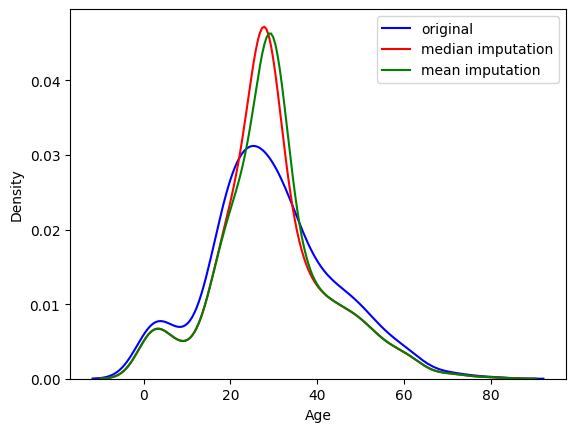

In [41]:
fig = plt.figure()
ax1 = fig.add_subplot(111)
sns.kdeplot(X_train['Age'], ax=ax1, color='blue', label='original')
sns.kdeplot(X_train['Age_median'], ax=ax1, color='red', label='median imputation')
sns.kdeplot(X_train['Age_mean'], ax=ax1, color='green', label='mean imputation')
ax1.legend()
plt.show()

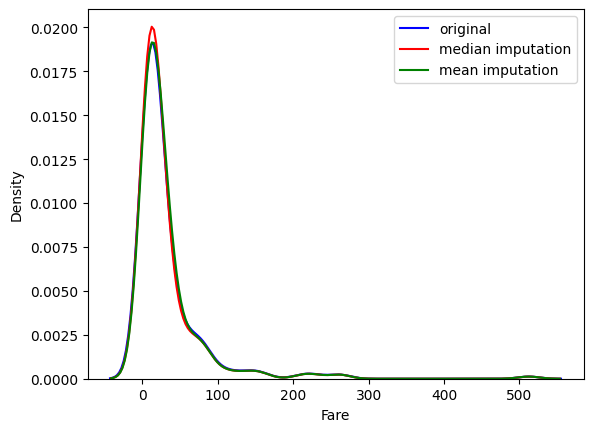

In [42]:
fig = plt.figure()
ax1 = fig.add_subplot(111)
sns.kdeplot(X_train['Fare'], ax=ax1, color='blue', label='original')
sns.kdeplot(X_train['Fare_median'], ax=ax1, color='red', label='median imputation')
sns.kdeplot(X_train['Fare_mean'], ax=ax1, color='green', label='mean imputation')
ax1.legend()
plt.show()

In [43]:
X_train.cov()

,Age,Fare,Family,Age_median,Fare_mean,Fare_median,Age_mean
Age,210.251707,75.481375,-6.993325,210.251707,71.193767,70.082085,210.251707
Fare,75.481375,2761.031435,18.599163,63.938058,2761.031435,2761.031435,60.224654
Family,-6.993325,18.599163,2.830892,-5.587710,17.657433,17.672035,-5.616299
Age_median,210.251707,63.938058,-5.587710,169.207310,60.700688,59.728510,168.851934
Fare_mean,71.193767,2761.031435,17.657433,60.700688,2621.232375,2621.232375,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,2621.232375,2637.012482,56.282518
Age_mean,210.251707,60.224654,-5.616299,168.851934,57.175304,56.282518,168.851934


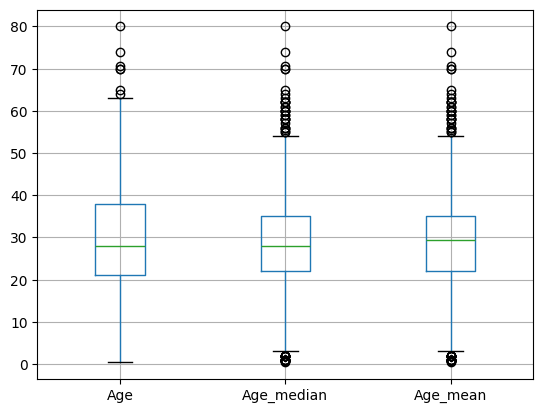

In [44]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()
plt.show()

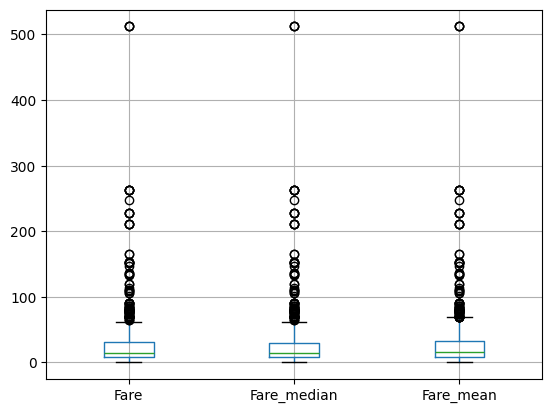

In [45]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()
plt.show()

### Using SKlearn

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

trf = ColumnTransformer([
    ('imputer_median', imputer1, ['Age']),
    ('imputer_mean', imputer2, ['Fare'])
], remainder='passthrough')

trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer_median', ...), ('imputer_mean', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [49]:
trf.named_transformers_['imputer_median'].statistics_

array([28.])

In [50]:
trf.named_transformers_['imputer_mean'].statistics_

array([32.51778772])

In [51]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [52]:
X_train

array([[ 45.5       ,  28.5       ,   0.        ],
       [ 23.        ,  13.        ,   0.        ],
       [ 32.        ,   7.925     ,   0.        ],
       ...,
       [ 41.        ,  32.51778772,   2.        ],
       [ 14.        , 120.        ,   3.        ],
       [ 21.        ,  77.2875    ,   1.        ]], shape=(712, 3))

##  Missing Indicator | Random Sample Imputation 

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split



In [56]:
df = pd.read_csv("train.csv", usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [57]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [58]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

